# 12 — Learned selector: the meta-controller conditions on trajectory features

Notebook 11's selector was a running average (EWMA surprise + ε-greedy). This
notebook is the next step from `docs/TRAINER.md` §6: a **learned selector**
that conditions on trajectory features and updates online from surprise.

It also uses the extracted `trainer/` package end-to-end for the first time —
the same code that `trainer/smoke_test.py` exercises with a synthetic adapter
now runs the three real small LLMs.

```text
features φ(t) = [bss(t), Δbss(t), DFT period, EWMA surprises, phase, bias]
                    │
                    ▼
   score_a(t) = w_a · φ(t)      one linear model per predictor,
                    │           ridge-fit online to reward = -surprise_a
                    ▼
   choice = ε-greedy argmax_a score_a(t)
```

Two selectors are compared on the **same open loop**, each driving its own
16-step closed loop with the real LLMs:

- `EwmaSelector` (notebook 11 baseline)
- `LearnedSelector` (new)

In [1]:
import os, sys

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import (
    EwmScene,
    EwmaSelector,
    LearnedSelector,
    LlmAdapter,
    default_portfolio,
    run_open_loop,
    run_closed_loop,
)

WORK = "/home/alexmy/.cache/ewm-multi-llm-learned"
os.makedirs(WORK, exist_ok=True)
ewm = EwmScene()

print("ewm-scene:", ewm.bin)
print("work:", WORK)

ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
work: /home/alexmy/.cache/ewm-multi-llm-learned


In [2]:
QUERIES = [
    "What is the capital of France?",
    "Explain gravity in one sentence.",
    "Write a haiku about rain.",
    "What is the meaning of life?",
    "Name three planets in our solar system.",
    "What is the speed of light?",
    "Define entropy in simple words.",
    "Who wrote Romeo and Juliet?",
]

# The three real small LLMs, loaded once on the pinned GPU.
adapter = LlmAdapter()
print("adapter names:", adapter.names)

adapter names: ('llm_a', 'llm_b', 'llm_c')


## §1 — Open loop: the shared Pavlov cycle

Both selectors are trained/evaluated from the same recorded cycle, so the
comparison starts from the same BSS prototypes and the same per-LLM frame.

In [3]:
open_result = run_open_loop(adapter, ewm, QUERIES, WORK, cycles=3, max_new_tokens=48)
print("IICA (union discovered twice):", open_result.same_union)
print("BSS trajectory:", open_result.M_ol.shape, "| prototypes:", open_result.M_proto.shape)
print("DFT-detected period:", open_result.period, "steps (true period 8)")

IICA (union discovered twice): True
BSS trajectory: (24, 3) | prototypes: (8, 3)
DFT-detected period: 8.0 steps (true period 8)


## §2 — Two selectors, two closed loops

Each selector drives the memory + curiosity loop for 16 steps. Per-predictor
surprise is observed every step (full feedback), so the learned selector's
online ridge fit has one training row per step after the first.

In [4]:
portfolio = default_portfolio()

ewma_selector = EwmaSelector(names=list(portfolio), eps=0.1, decay=0.8, warmup=2, seed=0)
result_ewma = run_closed_loop(
    adapter, ewm, open_result, portfolio, ewma_selector, QUERIES, WORK, T=16
)

def report(name, result):
    print(f"{name}:")
    print("  choices:", result.counts)
    for p in portfolio:
        print(f"    {p:12s} mean surprise {np.mean(result.surprise_all[p][1:]):.6f}")
    best = min(portfolio, key=lambda p: np.mean(result.surprise_all[p][1:]))
    ratio = (np.mean(result.surprise_meta[1:]) /
             max(np.mean(result.surprise_all[best][1:]), 1e-12))
    print(f"    meta mean surprise {np.mean(result.surprise_meta[1:]):.6f}  "
          f"(best single: {best})  meta/best = {ratio:.3f}")
    return ratio

ratio_ewma = report("EWMA selector", result_ewma)

EWMA selector:
  choices: {'persistence': 12, 'linear': 0, 'dft-periodic': 1, 'ridge': 2}
    persistence  mean surprise 0.045309
    linear       mean surprise 0.092926
    dft-periodic mean surprise 0.046456
    ridge        mean surprise 0.068700
    meta mean surprise 0.043154  (best single: persistence)  meta/best = 0.952


In [5]:
learned_selector = LearnedSelector(names=list(portfolio), eps=0.1, warmup=4, seed=0)
result_learned = run_closed_loop(
    adapter, ewm, open_result, portfolio, learned_selector, QUERIES, WORK, T=16
)
ratio_learned = report("learned selector", result_learned)

learned selector:
  choices: {'persistence': 2, 'linear': 1, 'dft-periodic': 2, 'ridge': 10}
    persistence  mean surprise 0.045309
    linear       mean surprise 0.092926
    dft-periodic mean surprise 0.046456
    ridge        mean surprise 0.068700
    meta mean surprise 0.050236  (best single: persistence)  meta/best = 1.109


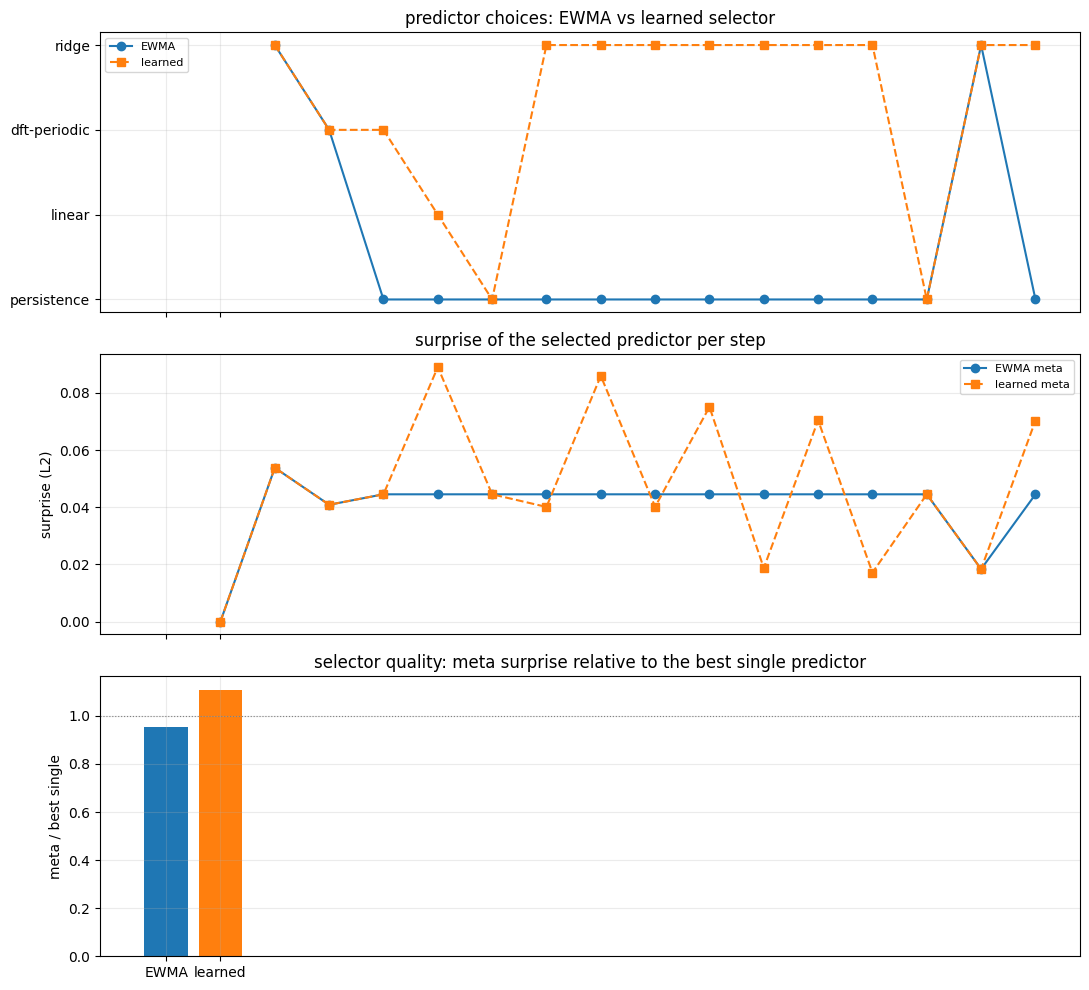

meta/best single: EWMA = 0.952 | learned = 1.109


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

names_p = list(portfolio)
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
t_axis = np.arange(1, 17)

def choice_idx(result):
    return [names_p.index(c) if c is not None else np.nan for c in result.choice_log]

axes[0].plot(t_axis, choice_idx(result_ewma), "o-", label="EWMA")
axes[0].plot(t_axis, choice_idx(result_learned), "s--", label="learned")
axes[0].set_yticks(range(len(names_p)), names_p)
axes[0].set_title("predictor choices: EWMA vs learned selector")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot(t_axis, result_ewma.surprise_meta, "o-", label="EWMA meta")
axes[1].plot(t_axis, result_learned.surprise_meta, "s--", label="learned meta")
axes[1].set_ylabel("surprise (L2)")
axes[1].set_title("surprise of the selected predictor per step")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

axes[2].bar([0, 1], [ratio_ewma, ratio_learned], color=["tab:blue", "tab:orange"])
axes[2].set_xticks([0, 1], ["EWMA", "learned"])
axes[2].set_ylabel("meta / best single")
axes[2].set_title("selector quality: meta surprise relative to the best single predictor")
axes[2].axhline(1.0, color="gray", ls=":", lw=0.8)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/learned_selector.png", dpi=110)
plt.show()

print("meta/best single: EWMA =", round(ratio_ewma, 3), "| learned =", round(ratio_learned, 3))

## Summary

- The `trainer/` package ran the full pipeline with the real LLMs: open loop
  recorded once, then two closed loops driven by two different selectors.
- The learned selector conditions on trajectory features (BSS, ΔBSS, DFT
  period, EWMA surprises, phase) and refits one linear model per predictor
  online from the full-feedback surprise.
- The `meta/best` ratio measures how close the selector gets to the best
  single predictor on its own trajectory (1.0 = optimal hindsight choice).

Next: give the learned selector a longer loop and let the surprise signal
also update the predictors themselves (e.g., a surprise-weighted ridge).